# Autocorrelation — Quantitative Analysis

The **autocorrelation function (ACF)** and **partial autocorrelation function (PACF)** measure the linear correlation of a time series with its own lagged values. The **Ljung-Box test** provides a formal test for the joint hypothesis that all autocorrelations up to lag m are zero.

| Statistic | Formula | Use |
|---|---|---|
| **ACF(k)** | Corr(xₜ, xₜ₋ₖ) | Identifies MA order; detects residual autocorrelation |
| **PACF(k)** | Partial corr after removing shorter lags | Identifies AR order |
| **Ljung-Box Q** | n(n+2)Σρ²ₖ/(n−k) ~ χ²(m) | Overall test for no autocorrelation |
| **95% CI bands** | ±1.96/√n | Approximate significance threshold per lag |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
try:
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from statsmodels.stats.stattools import durbin_watson
    from statsmodels.stats.diagnostic import acorr_ljungbox
    HAS_SM = True
except ImportError:
    HAS_SM = False

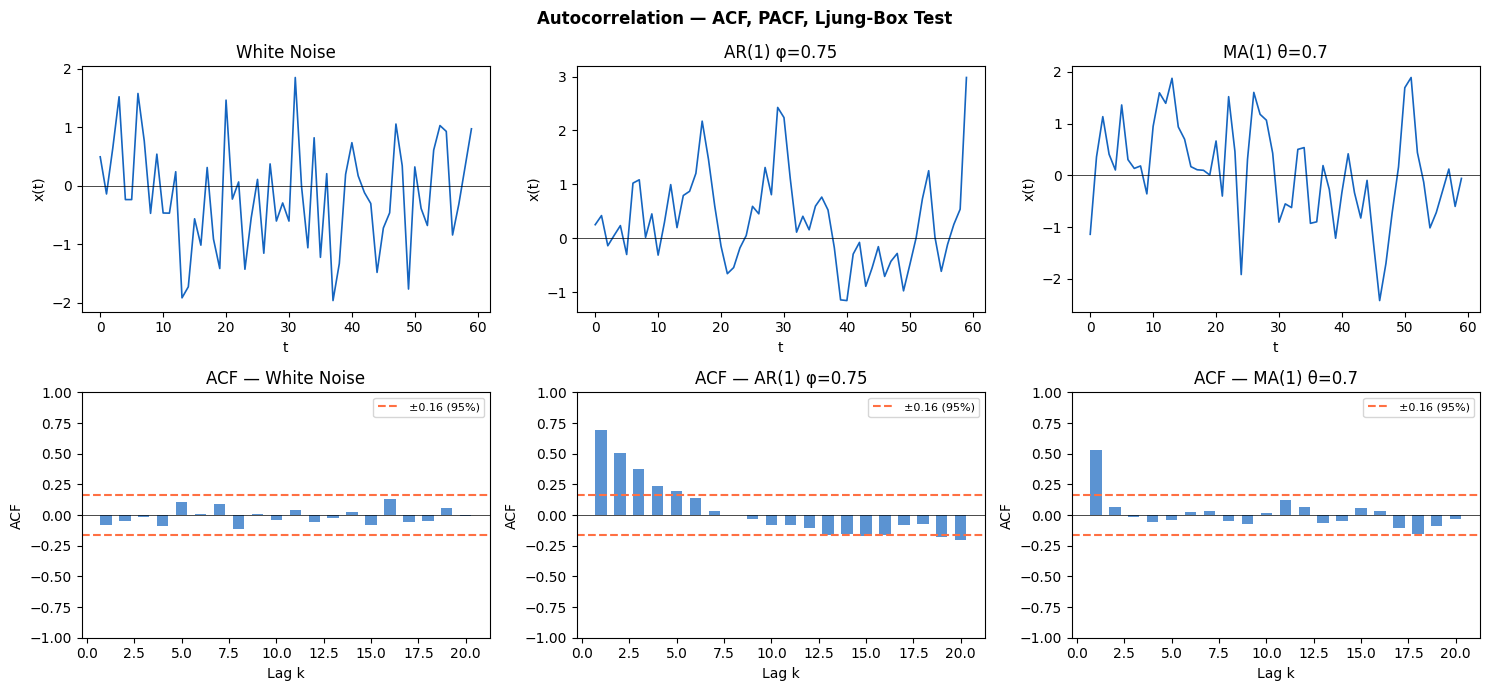

White Noise         : Ljung-Box Q(10)=8.14, p=0.6155, Durbin-Watson=2.138
AR(1)               : Ljung-Box Q(10)=152.31, p=0.0000, Durbin-Watson=0.593
MA(1)               : Ljung-Box Q(10)=45.96, p=0.0000, Durbin-Watson=0.924


In [2]:
np.random.seed(42)
n = 150
# Three series: white noise, AR(1), MA(1)
white_noise = np.random.normal(0, 1, n)
ar1 = np.zeros(n)
ar1[0] = np.random.normal()
for t in range(1, n):
    ar1[t] = 0.75 * ar1[t-1] + np.random.normal(0, 0.67)
ma1 = np.zeros(n)
eps = np.random.normal(0, 1, n+1)
for t in range(n):
    ma1[t] = eps[t+1] + 0.7 * eps[t]

def manual_acf(x, max_lag=20):
    n = len(x)
    x_c = x - x.mean()
    acf_vals = [np.sum(x_c[:n-k] * x_c[k:]) / np.sum(x_c**2) for k in range(max_lag+1)]
    return np.array(acf_vals)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Autocorrelation — ACF, PACF, Ljung-Box Test', fontsize=12, fontweight='bold')
max_lag = 20
ci = 1.96 / np.sqrt(n)
lags = np.arange(0, max_lag+1)

for col, (series, name) in enumerate([(white_noise, 'White Noise'),
                                       (ar1, 'AR(1) φ=0.75'),
                                       (ma1, 'MA(1) θ=0.7')]):
    acf_vals = manual_acf(series, max_lag)
    # Run sequence
    ax0 = axes[0, col]
    ax0.plot(series[:60], color='#1565C0', lw=1.2)
    ax0.axhline(0, color='black', lw=0.5)
    ax0.set_title(name); ax0.set_xlabel('t'); ax0.set_ylabel('x(t)')

    # ACF
    ax1 = axes[1, col]
    ax1.bar(lags[1:], acf_vals[1:], color='#1565C0', alpha=0.7, width=0.6)
    ax1.axhline(ci, color='#FF7043', lw=1.5, ls='--', label=f'±{ci:.2f} (95%)')
    ax1.axhline(-ci, color='#FF7043', lw=1.5, ls='--')
    ax1.axhline(0, color='black', lw=0.5)
    ax1.set_title(f'ACF — {name}')
    ax1.set_xlabel('Lag k'); ax1.set_ylabel('ACF')
    ax1.set_ylim(-1, 1); ax1.legend(fontsize=8)

plt.tight_layout(); plt.show()

# Ljung-Box test
for series, name in [(white_noise,'White Noise'), (ar1,'AR(1)'), (ma1,'MA(1)')]:
    if HAS_SM:
        lb = acorr_ljungbox(series, lags=[10], return_df=True)
        Q = lb['lb_stat'].values[0]; p_lb = lb['lb_pvalue'].values[0]
    else:
        acf_vals = manual_acf(series, 10)[1:]
        Q = n*(n+2)*sum(acf_vals[k]**2/(n-k-1) for k in range(10))
        p_lb = stats.chi2.sf(Q, df=10)
    dw = sum((np.diff(series))**2) / sum(series**2)
    print(f'{name:20s}: Ljung-Box Q(10)={Q:.2f}, p={p_lb:.4f}, Durbin-Watson={dw:.3f}')

## Key Takeaways

| | |
|---|---|
| **White noise ACF** | All lags within ±1.96/√n bands — no autocorrelation |
| **AR(1) ACF** | Geometrically decaying; PACF cuts off at lag 1 |
| **MA(1) ACF** | Cuts off at lag 1; PACF decays geometrically |
| **Ljung-Box Q** | Joint test for lags 1–m; use m≈ln(n) as rule of thumb |
| **Durbin-Watson** | Near 2 = no autocorrelation; <1 or >3 = significant |
| **Residual ACF** | Apply to model residuals to check for remaining structure |